<a href="https://colab.research.google.com/github/Ashishjoshi794/computer-vision/blob/main/2_hiden_linear_nn_for_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
IMG_HEIGHT = 254
IMG_WIDTH = 254
IMG_CHANNELS = 3
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]


In [ ]:
def read_and_decode(filename, resize_dims):
    # 1. Read the raw file
    img_bytes = tf.io.read_file(filename)
    # 2. Decode image data
    img = tf.image.decode_jpeg(img_bytes, channels=IMG_CHANNELS)
    # 3. Convert pixel values to floats in [0, 1]
    img = tf.image.convert_image_dtype(img, tf.float32)
    # 4. Resize the image to match desired dimensions
    img = tf.image.resize(img, resize_dims)
    return img

In [ ]:
def parse_csvline(csv_line):
    # record_defaults specify the data types for each column
    record_default = ["", ""]
    filename, label_string = tf.io.decode_csv(csv_line, record_default)

    # Load the image
    img = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

    # Convert label string to integer based on the CLASS_NAMES index
    label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
    return img, label

In [ ]:
import tensorflow as tf

read_and_decode= "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=read_and_decode,
    untar=True
)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
import os

print(os.listdir(data_dir))

['flower_photos']


In [ ]:
data_dir = os.path.join(data_dir, "flower_photos")

print(os.listdir(data_dir))

['roses', 'sunflowers', 'tulips', 'daisy', 'LICENSE.txt', 'dandelion']


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(254, 254),
    batch_size=16
)

eval_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(254, 254),
    batch_size=16
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
for image_batch, label_batch in train_dataset.take(2):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (16, 254, 254, 3)
Label batch shape: (16,)
Labels: [0 3 0 1 4 0 0 0 2 4 2 2 0 3 0 2]
Image batch shape: (16, 254, 254, 3)
Label batch shape: (16,)
Labels: [1 4 3 1 0 3 1 1 0 0 0 3 1 1 1 3]


Normalization


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

eval_dataset = eval_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

In [ ]:
for image_batch, label_batch in train_dataset.take(1):
    print("Image shape:", image_batch.shape)
    print("Min:", tf.reduce_min(image_batch).numpy())
    print("Max:", tf.reduce_max(image_batch).numpy())

Image shape: (16, 254, 254, 3)
Min: 0.0
Max: 1.0


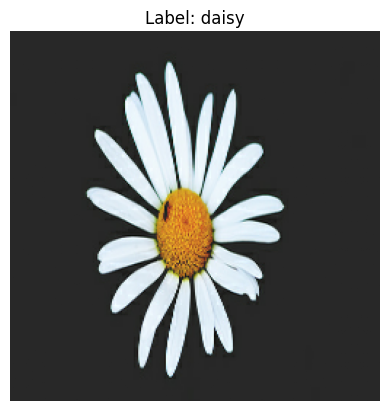

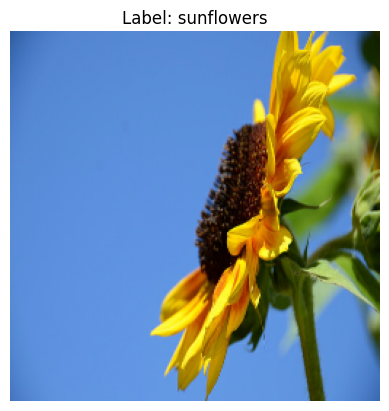

In [ ]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    # Take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    # Convert tensor to numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis('off')
    plt.show()

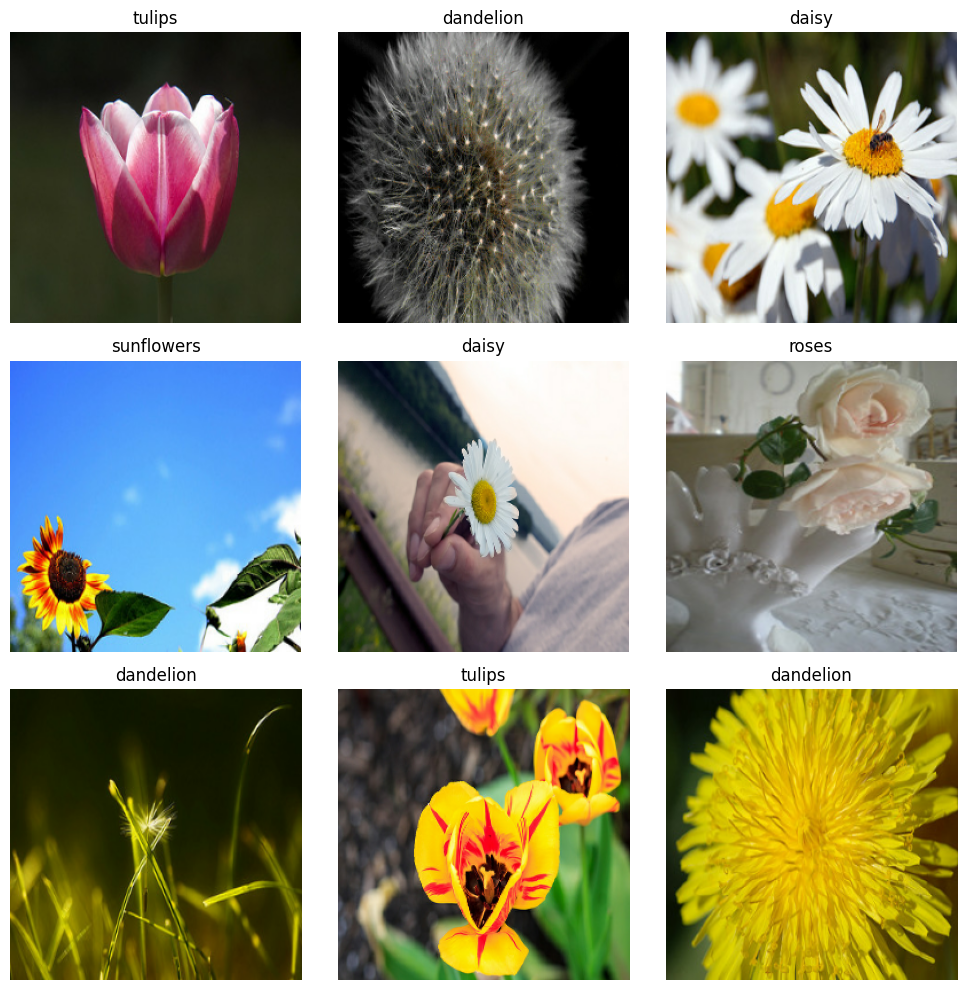

In [ ]:
plt.figure(figsize=(10, 10))
for i, (image_batch, label_batch) in enumerate(train_dataset.take(1)):
    for j in range(9):
        plt.subplot(3, 3, j + 1)
        plt.imshow(image_batch[j].numpy())
        plt.title(CLASS_NAMES[label_batch[j]])
        plt.axis('off')
    break # Only take one batch to display 9 images
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])

model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.2558 - loss: 1.6158 - val_accuracy: 0.2847 - val_loss: 1.5729
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.2612 - loss: 1.5843 - val_accuracy: 0.2616 - val_loss: 1.5945
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.2670 - loss: 1.5865 - val_accuracy: 0.2616 - val_loss: 1.5935
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.2439 - loss: 1.6005 - val_accuracy: 0.2643 - val_loss: 1.5908
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.2572 - loss: 1.5833 - val_accuracy: 0.2820 - val_loss: 1.5691
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.2912 - loss: 1.5357 - val_accuracy: 0.3610 - val_loss: 1.4808
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.3294 - loss: 1.4879 - val_accuracy: 0.2643 - val_loss: 1.5902
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.2721 - loss: 1.5636 - val_a

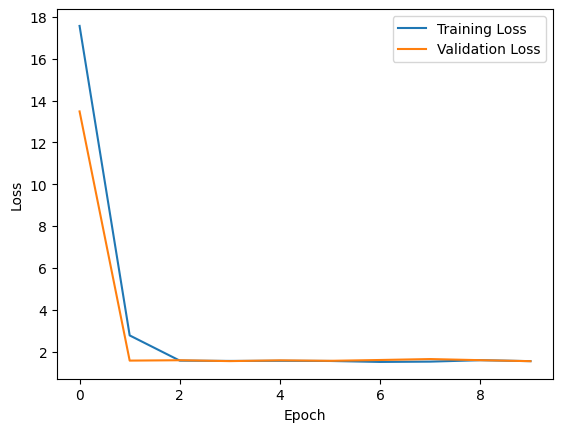

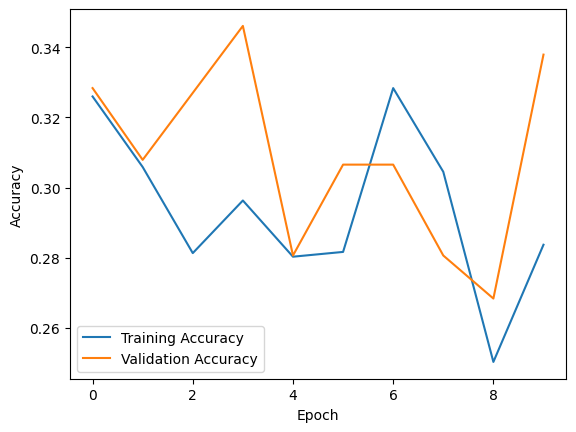

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


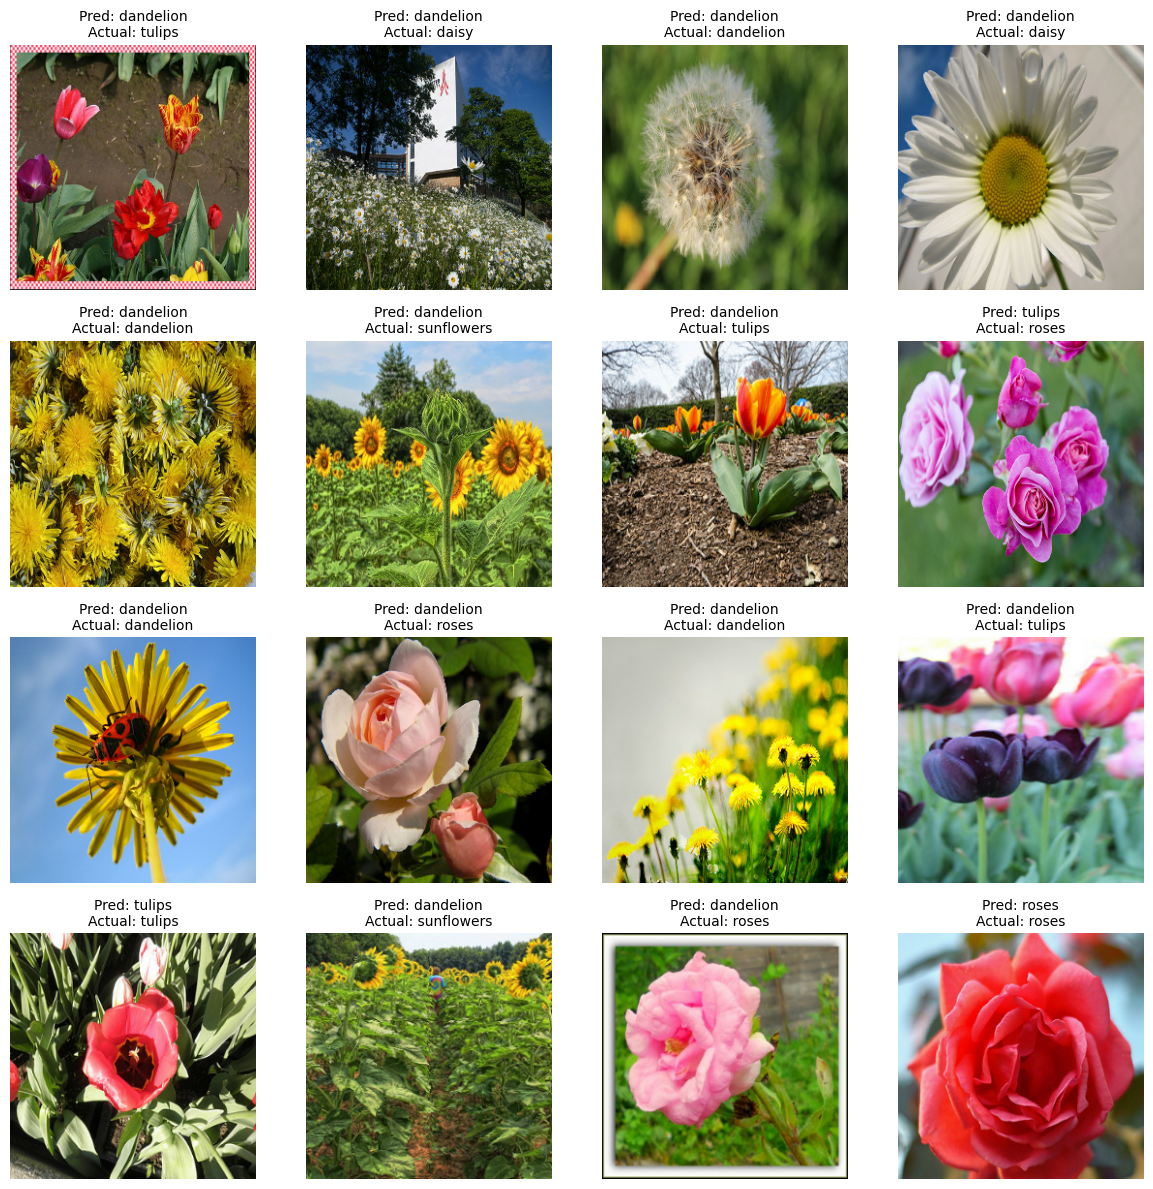

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Take exactly one batch from evaluation dataset
for images, labels in eval_dataset.take(1):

    # Get model predictions
    batch_predictions = model.predict(images)

    # Get predicted class index
    predicted_indices = np.argmax(batch_predictions, axis=1)

    # Number of images
    num_images = images.shape[0]

    # Images per row
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    # Create figure
    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):

        plt.subplot(num_rows, num_cols, i + 1)

        # Display image
        plt.imshow(images[i].numpy())
        plt.axis("off")

        # Get predicted and actual class names
        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        # Display prediction and actual label
        plt.title(
            f"Pred: {pred_class}\nActual: {actual_class}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()